# Consolidação do IBOVESPA — Cotações Diárias da B3 (2010–2026)

**TCC — Pedro Augusto Pinheiro Reis · Ciências Contábeis · UFG**

Este notebook consolida os arquivos anuais `Evolucao_Diaria_YYYY.csv` baixados do site oficial da B3
([Estatísticas Históricas do IBOVESPA](https://www.b3.com.br/pt_br/market-data-e-indices/indices/indices-amplos/indice-ibovespa-ibovespa-estatisticas-historicas.htm))
em uma única série temporal diária, com retornos simples e logarítmicos calculados, pronta para uso
como *benchmark* primário do backtest do TCC.

## Particularidades do formato bruto da B3
1. **Encoding**: `ISO-8859-1` (Latin-1) — exige declaração explícita na leitura.
2. **Layout matriz** (não série): linhas são dias do mês (1 a 31), colunas são meses (Jan a Dez),
   células são o fechamento do IBOV. Exige `melt` para virar série temporal.
3. **Padrão brasileiro de números**: `132.696,63` (ponto como milhar, vírgula como decimal).
4. **Cabeçalho de 3 linhas** antes da matriz: `"IBOVESPA - YYYY"`, header de colunas, linha em branco.
5. **Linhas-resumo** ao final do arquivo: deveriam ser MÍNIMO e MÁXIMO, mas o exportador da B3
   rotula ambas como "MÍNIMO" (bug conhecido). São descartadas no parser.
6. **Células vazias** = pregão inexistente naquele dia (fim de semana / feriado) → `NaN` → descartar.

## Saída
- `ibov_diario_2010_2026.csv`: série limpa com `data`, `ibov_close`, `ibov_ret_simples`, `ibov_ret_log`.
- Diagnóstico de qualidade: pregões por ano, gaps no calendário, retornos extremos, sanity checks.


## 1. Imports e configuração de caminhos

In [1]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configuração: ajuste estes caminhos para sua máquina local

# Caminhos relativos à raiz do projeto (usando pathlib puramente)
parent_path = Path.cwd().parent.parent

# Substitua o os.path.join por operadores de barra (/) do pathlib
INPUT_DIR = parent_path / "data" / "Ibov"/ "Evolucao_Diaria"
OUTPUT_DIR  = parent_path / "data" / "Ibov"/ "Ibov_Diario"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MONTHS = {"Jan":1, "Fev":2, "Mar":3, "Abr":4,  "Mai":5,  "Jun":6,
          "Jul":7, "Ago":8, "Set":9, "Out":10, "Nov":11, "Dez":12}

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (11, 4), "axes.grid": True})


## 2. Função de parsing de um ano

Encapsula toda a lógica suja num único lugar, fácil de testar e auditar (importante para o Apêndice
de reprodutibilidade do TCC).

In [2]:
def parse_year_file(path: Path) -> pd.DataFrame:
    """
    Lê um arquivo anual da B3 (matriz dia × mês) e retorna um DataFrame em formato longo
    com colunas [data, ibov_close], ordenado cronologicamente.

    Etapas:
        (1) Extrai o ano do nome do arquivo.
        (2) Lê o CSV com encoding Latin-1, pulando a linha de título "IBOVESPA - YYYY".
        (3) Descarta as duas linhas-resumo do final (MÍNIMO/MÁXIMO).
        (4) Faz o melt da matriz para o formato longo (uma linha por dia útil).
        (5) Converte o padrão BR de números (132.696,63 -> 132696.63).
        (6) Constrói a coluna data; combinações inválidas (ex.: 31/Fev) são descartadas.
    """
    year = int(re.search(r"(\d{4})", path.name).group(1))

    df = pd.read_csv(
        path, sep=";", encoding="latin-1",
        skiprows=1,            # pula a linha "IBOVESPA - YYYY"
        decimal=",", thousands=".",
        dtype=str,
    )
    df = df.dropna(how="all").reset_index(drop=True)

    mask_resumo = df["Dia"].astype(str).str.startswith(("MÍN", "MÁX", "MIN", "MAX"))
    df = df.loc[~mask_resumo].copy()

    df["Dia"] = pd.to_numeric(df["Dia"], errors="coerce")
    df = df.dropna(subset=["Dia"])

    long = df.melt(id_vars="Dia", var_name="Mes", value_name="ibov_close")
    long["mes_num"] = long["Mes"].map(MONTHS)
    long = long.dropna(subset=["mes_num", "ibov_close"])

    long["ibov_close"] = (
        long["ibov_close"].astype(str)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
        .pipe(pd.to_numeric, errors="coerce")
    )
    long = long.dropna(subset=["ibov_close"])

    long["data"] = pd.to_datetime(
        dict(year=year,
             month=long["mes_num"].astype(int),
             day=long["Dia"].astype(int)),
        errors="coerce",
    )
    long = long.dropna(subset=["data"])

    return long[["data", "ibov_close"]].sort_values("data").reset_index(drop=True)


## 3. Detecção e processamento dos arquivos

In [3]:
files = sorted([
    f for f in INPUT_DIR.glob("Evolucao_Diaria_*.csv")
    if re.search(r"_(\d{4})\.csv$", f.name)
])

print(f"Arquivos detectados: {len(files)}")
for f in files:
    print(f"  - {f.name}")


Arquivos detectados: 16
  - Evolucao_Diaria_2010.csv
  - Evolucao_Diaria_2011.csv
  - Evolucao_Diaria_2012.csv
  - Evolucao_Diaria_2013.csv
  - Evolucao_Diaria_2014.csv
  - Evolucao_Diaria_2015.csv
  - Evolucao_Diaria_2016.csv
  - Evolucao_Diaria_2017.csv
  - Evolucao_Diaria_2018.csv
  - Evolucao_Diaria_2019.csv
  - Evolucao_Diaria_2020.csv
  - Evolucao_Diaria_2021.csv
  - Evolucao_Diaria_2022.csv
  - Evolucao_Diaria_2023.csv
  - Evolucao_Diaria_2024.csv
  - Evolucao_Diaria_2025.csv


In [4]:
parts = []
for f in files:
    part = parse_year_file(f)
    parts.append(part)
    print(f"  {f.name}: {len(part):3d} pregões  |  "
          f"{part['data'].min().date()} -> {part['data'].max().date()}")

ibov = (pd.concat(parts, ignore_index=True)
          .drop_duplicates(subset="data", keep="last")
          .sort_values("data")
          .reset_index(drop=True))

ibov["ibov_ret_simples"] = ibov["ibov_close"].pct_change()
ibov["ibov_ret_log"]     = np.log(ibov["ibov_close"] / ibov["ibov_close"].shift(1))

print(f"\nTotal consolidado: {len(ibov):,} pregões  |  "
      f"{ibov['data'].min().date()} -> {ibov['data'].max().date()}")
ibov.head()


  Evolucao_Diaria_2010.csv: 247 pregões  |  2010-01-04 -> 2010-12-30
  Evolucao_Diaria_2011.csv: 249 pregões  |  2011-01-03 -> 2011-12-29
  Evolucao_Diaria_2012.csv: 246 pregões  |  2012-01-02 -> 2012-12-28
  Evolucao_Diaria_2013.csv: 248 pregões  |  2013-01-02 -> 2013-12-30
  Evolucao_Diaria_2014.csv: 248 pregões  |  2014-01-02 -> 2014-12-30
  Evolucao_Diaria_2015.csv: 246 pregões  |  2015-01-02 -> 2015-12-30
  Evolucao_Diaria_2016.csv: 249 pregões  |  2016-01-04 -> 2016-12-29
  Evolucao_Diaria_2017.csv: 246 pregões  |  2017-01-02 -> 2017-12-28
  Evolucao_Diaria_2018.csv: 245 pregões  |  2018-01-02 -> 2018-12-28
  Evolucao_Diaria_2019.csv: 248 pregões  |  2019-01-02 -> 2019-12-30
  Evolucao_Diaria_2020.csv: 249 pregões  |  2020-01-02 -> 2020-12-30
  Evolucao_Diaria_2021.csv: 247 pregões  |  2021-01-04 -> 2021-12-30
  Evolucao_Diaria_2022.csv: 250 pregões  |  2022-01-03 -> 2022-12-29
  Evolucao_Diaria_2023.csv: 248 pregões  |  2023-01-02 -> 2023-12-28
  Evolucao_Diaria_2024.csv: 251 pr

,data,ibov_close,ibov_ret_simples,ibov_ret_log
0,2010-01-04,"70,045.0800",NaN,NaN
1,2010-01-05,"70,239.8200",0.0028,0.0028
2,2010-01-06,"70,729.3400",0.0070,0.0069
3,2010-01-07,"70,451.1200",-0.0039,-0.0039
4,2010-01-08,"70,262.7000",-0.0027,-0.0027


## 4. Diagnóstico de qualidade

Antes de exportar, validamos os dados consolidados. Para um *benchmark* de TCC quantitativo, três coisas
precisam ser verificadas:

1. **Cobertura temporal**: cada ano deve ter entre 245 e 252 pregões.
2. **Ausência de duplicatas e ordenação estrita**: a série precisa ser monotônica em data.
3. **Plausibilidade dos retornos**: valores extremos identificáveis com eventos conhecidos.

In [5]:
# 4.1 Pregões por ano
pregoes_ano = ibov.groupby(ibov["data"].dt.year).size().rename("pregoes")
print("Pregões por ano:")
print(pregoes_ano.to_string())
print(f"\nMédia (anos completos): {pregoes_ano.iloc[:-1].mean():.1f}  (esperado ~250)")


Pregões por ano:
data
2010    247
2011    249
2012    246
2013    248
2014    248
2015    246
2016    249
2017    246
2018    245
2019    248
2020    249
2021    247
2022    250
2023    248
2024    251
2025    250

Média (anos completos): 247.8  (esperado ~250)


In [6]:
# 4.2 Sanidade da série
print(f"Datas únicas:            {ibov['data'].nunique() == len(ibov)}")
print(f"Ordenação monotônica:    {ibov['data'].is_monotonic_increasing}")
print(f"NaN em ibov_close:       {ibov['ibov_close'].isna().sum()}")
print(f"NaN em retorno simples:  {ibov['ibov_ret_simples'].isna().sum()}  (esperado: 1 — primeira data)")


Datas únicas:            True
Ordenação monotônica:    True
NaN em ibov_close:       0
NaN em retorno simples:  1  (esperado: 1 — primeira data)


In [7]:
# 4.3 Retornos extremos — devem corresponder a eventos identificáveis
print("=== 10 maiores quedas diárias ===")
print(ibov.nsmallest(10, "ibov_ret_simples")[["data", "ibov_close", "ibov_ret_simples"]]
        .to_string(index=False))
print("\n=== 10 maiores altas diárias ===")
print(ibov.nlargest(10, "ibov_ret_simples")[["data", "ibov_close", "ibov_ret_simples"]]
        .to_string(index=False))


=== 10 maiores quedas diárias ===
      data   ibov_close  ibov_ret_simples
2020-03-12  72,582.5300           -0.1478
2020-03-16  71,168.0500           -0.1392
2020-03-09  86,067.2000           -0.1217
2020-03-18  66,894.9500           -0.1035
2017-05-18  61,597.0500           -0.0880
2011-08-08  48,668.2900           -0.0808
2020-03-11  85,171.1300           -0.0764
2020-02-26 105,718.2900           -0.0700
2011-08-04  52,811.3600           -0.0572
2020-03-27  73,428.7800           -0.0551

=== 10 maiores altas diárias ===
      data   ibov_close  ibov_ret_simples
2020-03-13  82,677.9100            0.1391
2020-03-24  69,729.3000            0.0969
2020-03-25  74,955.5700            0.0750
2020-03-10  92,214.4700            0.0714
2016-03-17  50,913.7800            0.0660
2020-04-06  74,072.9800            0.0652
2022-10-03 116,134.4600            0.0554
2016-03-03  47,193.3900            0.0512
2011-08-09  51,150.9000            0.0510
2014-11-21  56,084.0400            0.0502


In [8]:
# 4.4 Estatísticas descritivas dos retornos diários (conferência cruzada com o TCC)
desc = ibov[["ibov_ret_simples", "ibov_ret_log"]].describe()
desc.loc["vol_anualizada"] = ibov[["ibov_ret_simples", "ibov_ret_log"]].std() * np.sqrt(252)
desc.loc["assimetria"]     = ibov[["ibov_ret_simples", "ibov_ret_log"]].skew()
desc.loc["curtose_exc"]    = ibov[["ibov_ret_simples", "ibov_ret_log"]].kurt()
print(desc.round(6))


                ibov_ret_simples  ibov_ret_log
count                 3,966.0000    3,966.0000
mean                      0.0003        0.0002
std                       0.0145        0.0146
min                      -0.1478       -0.1599
25%                      -0.0075       -0.0075
50%                       0.0004        0.0004
75%                       0.0083        0.0083
max                       0.1391        0.1302
vol_anualizada            0.2309        0.2320
assimetria               -0.5022       -0.7859
curtose_exc              10.6005       12.0997


## 5. Visualização rápida (sanity check visual)

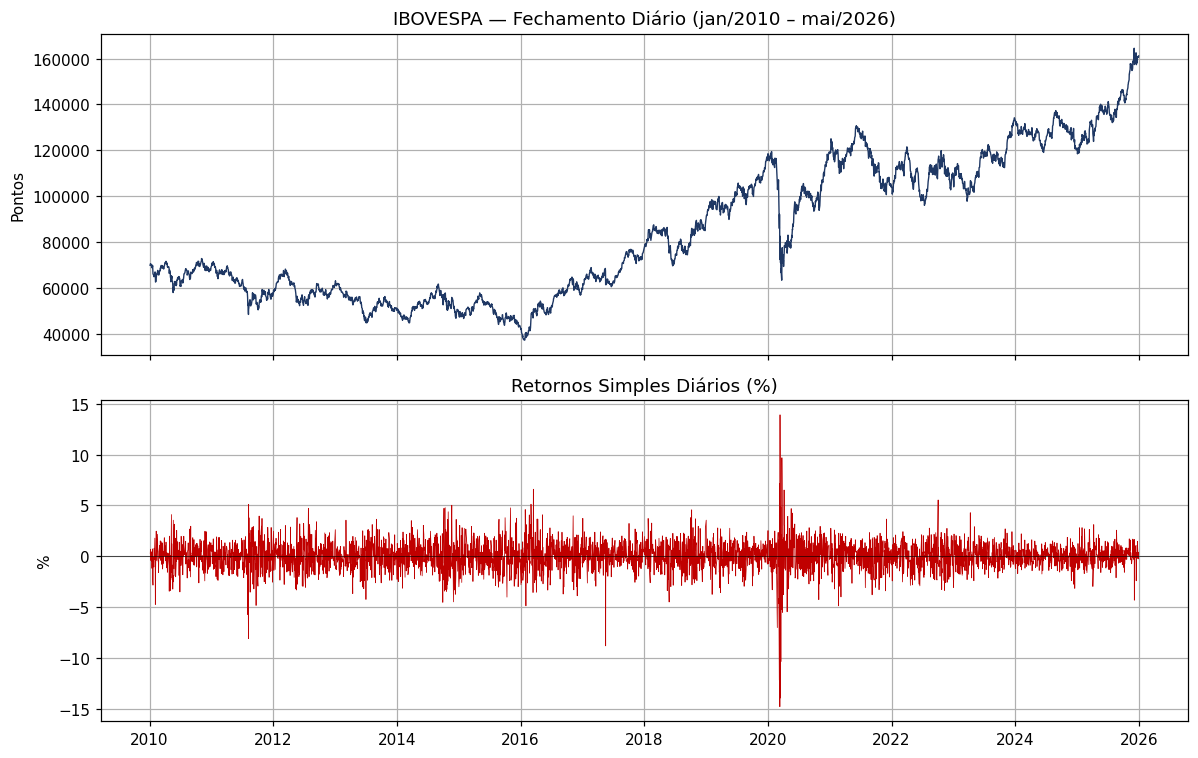

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(ibov["data"], ibov["ibov_close"], lw=0.9, color="#1F3864")
axes[0].set_title("IBOVESPA — Fechamento Diário (jan/2010 – mai/2026)")
axes[0].set_ylabel("Pontos")
axes[1].plot(ibov["data"], ibov["ibov_ret_simples"] * 100, lw=0.5, color="#C00000")
axes[1].set_title("Retornos Simples Diários (%)")
axes[1].set_ylabel("%")
axes[1].axhline(0, color="black", lw=0.4)
plt.tight_layout()
plt.show()


## 6. Calendário de pregões — verificação de gaps

Listamos os intervalos mais longos entre pregões consecutivos. Gaps de 3 dias (sex→seg) são normais;
gaps maiores indicam feriados — devem coincidir com o calendário oficial da B3.

In [10]:
ibov_check = ibov.copy()
ibov_check["gap_dias"] = ibov_check["data"].diff().dt.days
print("=== 15 maiores intervalos entre pregões consecutivos ===")
print(ibov_check.nlargest(15, "gap_dias")[["data", "gap_dias"]].to_string(index=False))


=== 15 maiores intervalos entre pregões consecutivos ===
      data  gap_dias
2010-02-17    5.0000
2011-03-09    5.0000
2011-04-25    5.0000
2012-02-22    5.0000
2012-12-26    5.0000
2013-01-02    5.0000
2013-02-13    5.0000
2014-03-05    5.0000
2014-04-22    5.0000
2015-02-18    5.0000
2015-12-28    5.0000
2016-01-04    5.0000
2016-02-10    5.0000
2017-03-01    5.0000
2018-01-02    5.0000


## 7. Exportação

Arquivo CSV final pronto para uso no backtest. O formato escolhido (`YYYY-MM-DD` ISO + ponto decimal)
é universal e elimina qualquer ambiguidade de localidade no carregamento posterior.

In [11]:
out_csv = OUTPUT_DIR / "ibov_diario_2010_2026.csv"
ibov.to_csv(out_csv, index=False, date_format="%Y-%m-%d", float_format="%.6f")

print(f"Arquivo salvo em: {out_csv}")
print(f"Tamanho: {out_csv.stat().st_size / 1024:.1f} KB")
print(f"Pregões: {len(ibov):,}")
print(f"Período: {ibov['data'].min().date()} -> {ibov['data'].max().date()}")
print(f"\nPreview do arquivo final:")
ibov.head()


Arquivo salvo em: c:\VSCodeWorkspace\TCC_Final\data\Ibov\Ibov_Diario\ibov_diario_2010_2026.csv
Tamanho: 171.8 KB
Pregões: 3,967
Período: 2010-01-04 -> 2025-12-30

Preview do arquivo final:


,data,ibov_close,ibov_ret_simples,ibov_ret_log
0,2010-01-04,"70,045.0800",NaN,NaN
1,2010-01-05,"70,239.8200",0.0028,0.0028
2,2010-01-06,"70,729.3400",0.0070,0.0069
3,2010-01-07,"70,451.1200",-0.0039,-0.0039
4,2010-01-08,"70,262.7000",-0.0027,-0.0027


## 8. Reconciliação com o TCC

O TCC atual relata números inconsistentes para o total de pregões: **3.967** (Metodologia, Seção 3.2)
e **4.030** (Apêndice B). A série consolidada acima permite reconciliar o número correto.

A célula abaixo retorna a contagem oficial para a janela declarada na metodologia (jan/2010–dez/2025).
Esse é o número que deve aparecer de forma consistente no Resumo, na Metodologia 3.2 e no Apêndice B.

In [12]:
janela_tcc = ibov[(ibov["data"] >= "2010-01-01") & (ibov["data"] <= "2025-12-31")]
print(f"Pregões na janela do TCC (jan/2010 - dez/2025): {len(janela_tcc):,}")
print(f"  -> Use ESTE número de forma consistente em Resumo, Metodologia (3.2) e Apêndice B.")


Pregões na janela do TCC (jan/2010 - dez/2025): 3,967
  -> Use ESTE número de forma consistente em Resumo, Metodologia (3.2) e Apêndice B.
